In [16]:
# Cell 1 — setup
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings import BRONZE_DIR, SILVER_DIR
from data.timetable import (
    add_segment_type,
    add_dynamics,
    add_period,
    add_time_in_seconds,
    add_train_type,
)

DISTRIBUTIONS_DIR = Path.cwd().parent / 'data' / 'distributions'
DISTRIBUTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Grens disturbance vs disruption
# Rijtijden buiten [PLANNED * MIN_FACTOR, PLANNED * MAX_FACTOR] worden als disruption beschouwd
MIN_FACTOR = 0.3   # rijtijd minder dan 30% van gepland → disruption
MAX_FACTOR = 3   # rijtijd meer dan 300% van gepland → disruption

In [17]:
# Cell 2 — laad brons
bronze_files = sorted(BRONZE_DIR.glob('*.parquet'))
df = pd.concat([pd.read_parquet(f) for f in bronze_files], ignore_index=True)
print(f"{df['DATDEP'].nunique()} dagen, {df['TRAIN_NO'].nunique()} treinen, {len(df)} rijen")
print(f"Datumrange: {df['DATDEP'].min()} → {df['DATDEP'].max()}")

260 dagen, 1365 treinen, 2618072 rijen
Datumrange: 2025-03-03 00:00:00 → 2026-02-27 00:00:00


In [18]:
# Cell 3 — verrijking (geen aggregatie, alle dagen behouden)
# assign_platforms wordt NIET toegepast: platformtoewijzing is een eigenschap
# van de geplande timetable, niet van individuele observaties.
# SECTION blijft zonder platform suffix — rijtijden worden gemeten per fysieke sectie.
df['LINE_NO_DEP'] = df['LINE_NO_DEP'].str.replace('/', '-')
dwell_mask = df['SOURCE'] == df['TARGET']
df['SECTION'] = np.where(
    dwell_mask,
    df['SOURCE'].astype(str),
    df['LINE_NO_DEP'].astype(str) + ':' + df['SOURCE'].astype(str) + '-' + df['TARGET'].astype(str)
)

df = add_segment_type(df)    # vereist PLANNED_ENTRY/EXIT als datetime, vóór add_time_in_seconds
df = add_period(df)          # vereist PLANNED_EXIT als datetime, vóór add_time_in_seconds
df = add_time_in_seconds(df) # converteert PLANNED_ENTRY/EXIT naar ENTRY/EXIT_SECONDS
df = add_dynamics(df)        # vereist TYPE en ENTRY_SECONDS
df = add_train_type(df)      # vereist RELATION_DIRECTION

df = df[df['TYPE'] != 'WITHIN-STATION-PASSING']

print(f"{df['SECTION'].nunique()} unieke secties, {len(df)} observaties")
print(f"Dynamics:   {df['DYNAMICS'].value_counts().to_dict()}")
print(f"Periodes:   {df['PERIOD'].value_counts().to_dict()}")
print(f"Traintypes: {df['TRAIN_TYPE'].value_counts().to_dict()}")

122 unieke secties, 2072118 observaties
Dynamics:   {'0-0': 889695, 'ACC-0': 554997, '0-BR': 553564, 'ACC-BR': 73862}
Periodes:   {'DAYTIME': 833634, 'EVENING': 459201, 'EVENING PEAK': 361235, 'MORNING PEAK': 343418, 'NIGHT': 74630}
Traintypes: {'IC': 1254018, 'L': 549364, 'S': 155694, 'EURST': 52505, 'INT': 37862, 'ICE': 22662, 'TGV': 13}


In [19]:
# Cell 4 — bereken rijtijden in seconden
df['RUNNING_TIME_PLANNED'] = df['EXIT_SECONDS'] - df['ENTRY_SECONDS']

# Werkelijke rijtijd: REAL_ENTRY <= REAL_EXIT altijd (geen swap nodig)
df['REAL_ENTRY'] = pd.to_datetime(df['REAL_ENTRY'])
df['REAL_EXIT']  = pd.to_datetime(df['REAL_EXIT'])

df['RUNNING_TIME_REAL'] = (df['REAL_EXIT'] - df['REAL_ENTRY']).dt.total_seconds()

n_before = len(df)
df = df.dropna(subset=['RUNNING_TIME_REAL', 'RUNNING_TIME_PLANNED'])
df = df[df['RUNNING_TIME_REAL']    > 0]
df = df[df['RUNNING_TIME_PLANNED'] > 0]
print(f"{n_before - len(df)} rijen verwijderd")
print(f"{len(df)} observaties beschikbaar")

2107 rijen verwijderd
2070011 observaties beschikbaar


=== Rijtijdstatistieken ===
       RUNNING_TIME_REAL  RUNNING_TIME_PLANNED
count          2070011.0             2070011.0
mean               145.3                 141.2
std                 90.5                  98.6
min                  1.0                   1.0
25%                 92.0                 120.0
50%                125.0                 120.0
75%                170.0                 180.0
max              17158.0               86650.0

Ratio werkelijk/gepland:
count    2070011.000
mean           1.118
std            0.947
min            0.003
25%            0.808
50%            1.017
75%            1.226
max          713.000
Name: RT_RATIO, dtype: float64

Ratio < 0.3 (te snel): 1366
Ratio > 3 (te traag): 24770


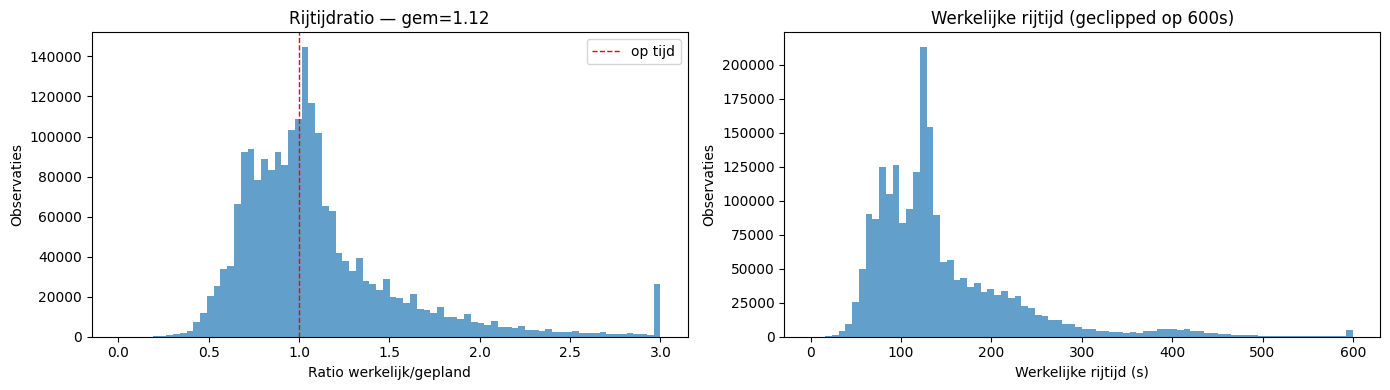

In [20]:
# Cell 5 — validatie rijtijden
print("=== Rijtijdstatistieken ===")
print(df[['RUNNING_TIME_REAL', 'RUNNING_TIME_PLANNED']].describe().round(1))

df['RT_RATIO'] = df['RUNNING_TIME_REAL'] / df['RUNNING_TIME_PLANNED']
print(f"\nRatio werkelijk/gepland:")
print(df['RT_RATIO'].describe().round(3))
print(f"\nRatio < {MIN_FACTOR} (te snel): {(df['RT_RATIO'] < MIN_FACTOR).sum()}")
print(f"Ratio > {MAX_FACTOR} (te traag): {(df['RT_RATIO'] > MAX_FACTOR).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['RT_RATIO'].clip(0, 3), bins=80, edgecolor='none', alpha=0.7)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1, label='op tijd')
axes[0].set_xlabel('Ratio werkelijk/gepland')
axes[0].set_ylabel('Observaties')
axes[0].set_title(f'Rijtijdratio — gem={df["RT_RATIO"].mean():.2f}')
axes[0].legend()

axes[1].hist(df['RUNNING_TIME_REAL'].clip(0, 600), bins=80, edgecolor='none', alpha=0.7)
axes[1].set_xlabel('Werkelijke rijtijd (s)')
axes[1].set_ylabel('Observaties')
axes[1].set_title('Werkelijke rijtijd (geclipped op 600s)')
plt.tight_layout()
plt.show()

In [21]:
# Cell 6 — filter disruptions
n_before = len(df)
df_dist = df[
    (df['RT_RATIO'] >= MIN_FACTOR) &
    (df['RT_RATIO'] <= MAX_FACTOR)
].copy()
print(f"{n_before - len(df_dist)} observaties verwijderd als disruption")
print(f"{len(df_dist)} observaties behouden ({100*len(df_dist)/n_before:.1f}% van totaal)")

26136 observaties verwijderd als disruption
2043875 observaties behouden (98.7% van totaal)


In [22]:
# Cell 7 — distributies opbouwen
# Structuur: distributions[section][train_type][dynamics][period]
#   → { 'real': [float, ...], 'n': int }
distributions = {}
n_cells = 0

for (section, train_type, dynamics, period), group in df_dist.groupby(
    ['SECTION', 'TRAIN_TYPE', 'DYNAMICS', 'PERIOD']
):
    real_values = group['RUNNING_TIME_REAL'].dropna().round(1).sort_values().tolist()

    if not real_values:
        continue

    distributions \
        .setdefault(section, {}) \
        .setdefault(train_type, {}) \
        .setdefault(dynamics, {})[period] = {
            'real': real_values,
            'n':    len(real_values),
        }
    n_cells += 1

print(f"Cellen opgeslagen: {n_cells}")
print(f"Unieke secties:    {len(distributions)}")

Cellen opgeslagen: 2457
Unieke secties:    100


In [23]:
# Cell 8 — opslaan
output_path = DISTRIBUTIONS_DIR / 'running_distributions.json'
with open(output_path, 'w') as f:
    json.dump(distributions, f)
size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"Opgeslagen: {output_path} ({size_mb:.2f} MB)")

Opgeslagen: /Users/ddw/Desktop/Rescheduling/data/distributions/running_distributions.json (13.13 MB)


Voorbeeldcel: 0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES | EURST | 0-0 | DAYTIME
  n=2513
  real (eerste 10): [63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0]


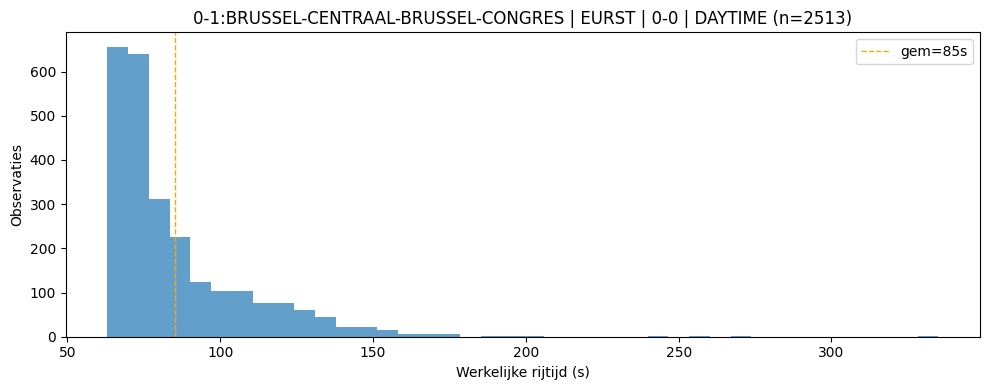

In [24]:
# Cell 9 — validatie output
with open(DISTRIBUTIONS_DIR / 'running_distributions.json') as f:
    loaded = json.load(f)

example_section    = next(iter(loaded))
example_train_type = next(iter(loaded[example_section]))
example_dynamics   = next(iter(loaded[example_section][example_train_type]))
example_period     = next(iter(loaded[example_section][example_train_type][example_dynamics]))
example_cell       = loaded[example_section][example_train_type][example_dynamics][example_period]

print(f"Voorbeeldcel: {example_section} | {example_train_type} | {example_dynamics} | {example_period}")
print(f"  n={example_cell['n']}")
print(f"  real (eerste 10): {example_cell['real'][:10]}")

real_vals = np.array(example_cell['real'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(real_vals, bins=40, edgecolor='none', alpha=0.7)
ax.axvline(float(np.mean(real_vals)), color='orange', linestyle='--', linewidth=1,
           label=f'gem={np.mean(real_vals):.0f}s')
ax.set_xlabel('Werkelijke rijtijd (s)')
ax.set_ylabel('Observaties')
ax.set_title(
    f'{example_section} | {example_train_type} | {example_dynamics} | {example_period} (n={len(real_vals)})'
)
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# Analyse verschil tussen distributies en geplande rijtijd
# voor segment: 36N:SCHAARBEEK-BRUSSEL-NOORD

import numpy as np
import pandas as pd
from data.running_distributions import _load
from data.combine_timetable import combine_timetables

SEGMENT = "36N:SCHAARBEEK-BRUSSEL-NOORD"

# ------------------------------------------------------------
# Laad distributies
# ------------------------------------------------------------
dist = _load()

if SEGMENT not in dist:
    raise ValueError(f"Segment {SEGMENT} niet gevonden")

# ------------------------------------------------------------
# Laad timetable
# ------------------------------------------------------------
df = combine_timetables(n_freight=257)

# Enkel dit segment
seg_df = df[df["SECTION"] == SEGMENT].copy()

# Geplande rijtijd berekenen
seg_df["planned_runtime"] = (
    seg_df["EXIT_SECONDS"] - seg_df["ENTRY_SECONDS"]
)

# Lookup:
# (train_type, dynamics, period) -> mediane geplande rijtijd
planned_lookup = (
    seg_df.groupby(["TRAIN_TYPE", "DYNAMICS", "PERIOD"])["planned_runtime"]
    .median()
    .to_dict()
)

# ------------------------------------------------------------
# Analyse
# ------------------------------------------------------------
rows = []

for train_type, dyn_dict in dist[SEGMENT].items():

    for dynamics, period_dict in dyn_dict.items():

        for period, cell in period_dict.items():

            real = np.array(cell["real"])

            planned = planned_lookup.get(
                (train_type, dynamics, period)
            )

            if planned is None:
                continue

            diff = real - planned

            rows.append({
                "train_type": train_type,
                "dynamics": dynamics,
                "period": period,
                "n_samples": len(real),

                "planned_time": planned,

                "mean_real": real.mean(),
                "median_real": np.median(real),
                "std_real": real.std(),

                "mean_diff": diff.mean(),
                "median_diff": np.median(diff),

                "pct_slower_than_planned":
                    (diff > 0).mean() * 100,

                "min_real": real.min(),
                "max_real": real.max(),
            })

results = pd.DataFrame(rows)

results = results.sort_values(
    ["train_type", "dynamics", "period"]
).reset_index(drop=True)

pd.set_option("display.max_columns", None)

display(results)

# ------------------------------------------------------------
# Globale samenvatting
# ------------------------------------------------------------
all_real = []
all_planned = []

for _, row in results.iterrows():
    train_type = row["train_type"]
    dynamics   = row["dynamics"]
    period     = row["period"]

    real = np.array(
        dist[SEGMENT][train_type][dynamics][period]["real"]
    )

    planned = row["planned_time"]

    all_real.extend(real)
    all_planned.extend([planned] * len(real))

all_real = np.array(all_real)
all_planned = np.array(all_planned)

diff = all_real - all_planned

print("\n================ GLOBAL SUMMARY ================\n")
print(f"Segment: {SEGMENT}")
print(f"Mean planned:      {all_planned.mean():.2f}s")
print(f"Mean real:         {all_real.mean():.2f}s")
print(f"Median real:       {np.median(all_real):.2f}s")
print(f"Mean difference:   {diff.mean():.2f}s")
print(f"Median difference: {np.median(diff):.2f}s")
print(f"Std deviation:     {all_real.std():.2f}s")
print(f"% slower than planned: {(diff > 0).mean()*100:.2f}%")

,train_type,dynamics,period,n_samples,planned_time,mean_real,median_real,std_real,mean_diff,median_diff,pct_slower_than_planned,min_real,max_real
0,EURST,ACC-0,DAYTIME,15,180.0,171.333333,165.0,22.959868,-8.666667,-15.0,26.666667,143.0,228.0
1,EURST,ACC-0,EVENING,6,180.0,183.000000,177.0,34.660256,3.000000,-3.0,50.000000,145.0,253.0
2,EURST,ACC-0,EVENING PEAK,7,180.0,196.428571,195.0,45.906293,16.428571,15.0,71.428571,137.0,288.0
3,EURST,ACC-0,MORNING PEAK,5,180.0,185.400000,191.0,28.793055,5.400000,11.0,60.000000,149.0,223.0
4,IC,ACC-BR,DAYTIME,41,180.0,219.024390,206.0,49.967544,39.024390,26.0,87.804878,170.0,435.0
5,IC,ACC-BR,EVENING,26,180.0,204.000000,194.0,31.687173,24.000000,14.0,73.076923,170.0,300.0
6,IC,ACC-BR,EVENING PEAK,17,180.0,205.470588,201.0,22.999022,25.470588,21.0,88.235294,177.0,253.0
7,IC,ACC-BR,MORNING PEAK,16,180.0,218.812500,225.5,28.111872,38.812500,45.5,87.500000,173.0,263.0
8,IC,ACC-BR,NIGHT,7,180.0,213.000000,222.0,29.456990,33.000000,42.0,71.428571,177.0,251.0
9,ICE,ACC-BR,DAYTIME,4,180.0,259.000000,233.0,48.579831,79.000000,53.0,100.000000,227.0,343.0



================ GLOBAL SUMMARY ================

Segment: 36N:SCHAARBEEK-BRUSSEL-NOORD
Mean planned:      180.00s
Mean real:         203.03s
Median real:       196.00s
Mean difference:   23.03s
Median difference: 16.00s
Std deviation:     42.03s
% slower than planned: 69.51%


In [26]:
# Check hoeveel segmenten overlappen tussen passenger en freight

import pandas as pd
from data.combine_timetable import combine_timetables
from data.timetable import load_gold

# ------------------------------------------------------------
# Laad data
# ------------------------------------------------------------
passenger = load_gold("passenger")
freight   = load_gold("freight", n_trains=257)

# ------------------------------------------------------------
# Unieke segmenten
# ------------------------------------------------------------
passenger_segments = set(passenger["SECTION"].unique())
freight_segments   = set(freight["SECTION"].unique())

# ------------------------------------------------------------
# Overlap
# ------------------------------------------------------------
overlap_segments = passenger_segments & freight_segments

only_passenger = passenger_segments - freight_segments
only_freight   = freight_segments - passenger_segments

# ------------------------------------------------------------
# Resultaten
# ------------------------------------------------------------
print("============== SEGMENT OVERLAP ==============\n")

print(f"Passenger segmenten: {len(passenger_segments)}")
print(f"Freight segmenten:   {len(freight_segments)}")
print(f"Overlap segmenten:   {len(overlap_segments)}")

print("\nPercentage freight dat overlap heeft:")
print(f"{100 * len(overlap_segments) / len(freight_segments):.2f}%")

print("\nPercentage passenger dat overlap heeft:")
print(f"{100 * len(overlap_segments) / len(passenger_segments):.2f}%")

# ------------------------------------------------------------
# Toon overlappende segmenten
# ------------------------------------------------------------
print("\n============== OVERLAPPENDE SEGMENTEN ==============\n")

for seg in sorted(overlap_segments):
    print(seg)

# ------------------------------------------------------------
# Segmenten enkel freight
# ------------------------------------------------------------
print("\n============== ENKEL FREIGHT ==============\n")

for seg in sorted(only_freight):
    print(seg)

# ------------------------------------------------------------
# Segmenten enkel passenger
# ------------------------------------------------------------
print("\n============== ENKEL PASSENGER ==============\n")

for seg in sorted(only_passenger):
    print(seg)

============== SEGMENT OVERLAP ==============

Passenger segmenten: 73
Freight segmenten:   26
Overlap segmenten:   21

Percentage freight dat overlap heeft:
80.77%

Percentage passenger dat overlap heeft:
28.77%

============== OVERLAPPENDE SEGMENTEN ==============

25:BRUSSEL-NOORD-SCHAARBEEK
28(1):BRUSSEL-WEST-BRUSSEL-ZUID
28(1):BRUSSEL-WEST-SIMONIS
28(1):BRUSSEL-ZUID-BRUSSEL-WEST
28(1):SIMONIS-BRUSSEL-WEST
28(1):SIMONIS-THURN EN TAXIS
28(1):THURN EN TAXIS-SIMONIS
36N:SCHAARBEEK-BRUSSEL-NOORD
50:BOCKSTAEL-BRUSSEL-NOORD
50:BOCKSTAEL-JETTE
50:BRUSSEL-NOORD-BOCKSTAEL
50:JETTE-BOCKSTAEL
50C:ANDERLECHT-BRUSSEL-ZUID
50C:BRUSSEL-ZUID-ANDERLECHT
60:JETTE-ZELLIK
60:ZELLIK-JETTE
BOCKSTAEL
BRUSSEL-WEST
JETTE
SIMONIS
THURN EN TAXIS

============== ENKEL FREIGHT ==============

26:BRUSSEL-SCHUMAN-SCHAARBEEK
26:SCHAARBEEK-BRUSSEL-SCHUMAN
28:SCHAARBEEK-THURN EN TAXIS
28:THURN EN TAXIS-SCHAARBEEK
SCHAARBEEK

============== ENKEL PASSENGER ==============

0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES
0-1:BRU


============== OVERLAPPENDE SEGMENTEN ==============



,n_passenger,n_freight,total_trains
SECTION,,,
36N:SCHAARBEEK-BRUSSEL-NOORD,143,110,253
25:BRUSSEL-NOORD-SCHAARBEEK,104,100,204
JETTE,163,8,171
BOCKSTAEL,134,8,142
SIMONIS,29,80,109
BRUSSEL-WEST,29,80,109
THURN EN TAXIS,29,80,109
50C:BRUSSEL-ZUID-ANDERLECHT,83,14,97
50C:ANDERLECHT-BRUSSEL-ZUID,80,11,91


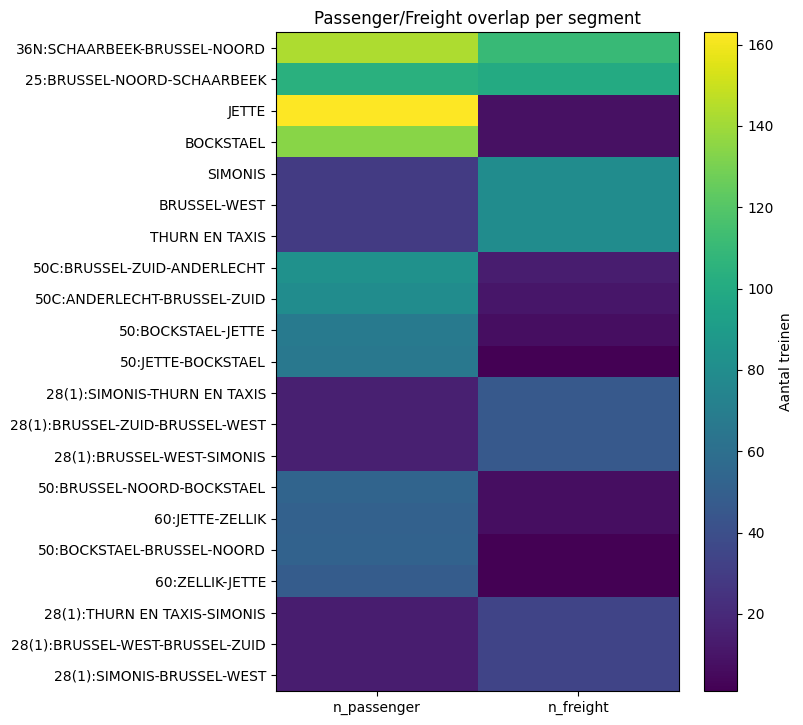


============== STATISTIEKEN ==============

Aantal overlappende segmenten: 21

Top 10 drukste overlappende segmenten:



,n_passenger,n_freight,total_trains
SECTION,,,
36N:SCHAARBEEK-BRUSSEL-NOORD,143,110,253
25:BRUSSEL-NOORD-SCHAARBEEK,104,100,204
JETTE,163,8,171
BOCKSTAEL,134,8,142
SIMONIS,29,80,109
BRUSSEL-WEST,29,80,109
THURN EN TAXIS,29,80,109
50C:BRUSSEL-ZUID-ANDERLECHT,83,14,97
50C:ANDERLECHT-BRUSSEL-ZUID,80,11,91



Gemiddeld aantal passenger treinen op overlapsegment:
58.04761904761905

Gemiddeld aantal freight treinen op overlapsegment:
35.95238095238095


In [27]:
# ============================================================
# HEATMAP VAN OVERLAP TUSSEN PASSENGER EN FREIGHT
# + aantal treinen per overlappend segment
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from data.timetable import load_gold

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
N_FREIGHT = 257

# ------------------------------------------------------------
# DATA LADEN
# ------------------------------------------------------------
passenger = load_gold("passenger")
freight   = load_gold("freight", n_trains=N_FREIGHT)

# ------------------------------------------------------------
# Unieke treinen per segment
# ------------------------------------------------------------
passenger_counts = (
    passenger.groupby("SECTION")["TRAIN_NO"]
    .nunique()
    .rename("n_passenger")
)

freight_counts = (
    freight.groupby("SECTION")["TRAIN_NO"]
    .nunique()
    .rename("n_freight")
)

# ------------------------------------------------------------
# Combineer
# ------------------------------------------------------------
overlap = pd.concat(
    [passenger_counts, freight_counts],
    axis=1
).fillna(0)

overlap["n_passenger"] = overlap["n_passenger"].astype(int)
overlap["n_freight"]   = overlap["n_freight"].astype(int)

# Enkel segmenten waar BEIDE rijden
overlap = overlap[
    (overlap["n_passenger"] > 0)
    &
    (overlap["n_freight"] > 0)
].copy()

# Totale drukte
overlap["total_trains"] = (
    overlap["n_passenger"]
    + overlap["n_freight"]
)

# Sorteer
overlap = overlap.sort_values(
    "total_trains",
    ascending=False
)

# ------------------------------------------------------------
# Toon tabel
# ------------------------------------------------------------
print("\n============== OVERLAPPENDE SEGMENTEN ==============\n")
display(overlap)

# ------------------------------------------------------------
# HEATMAP
# ------------------------------------------------------------
heatmap_df = overlap[
    ["n_passenger", "n_freight"]
]

plt.figure(figsize=(8, max(4, len(heatmap_df) * 0.35)))

plt.imshow(
    heatmap_df.values,
    aspect='auto'
)

plt.xticks(
    range(len(heatmap_df.columns)),
    heatmap_df.columns
)

plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index
)

plt.colorbar(label="Aantal treinen")

plt.title(
    "Passenger/Freight overlap per segment"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# EXTRA STATISTIEKEN
# ------------------------------------------------------------
print("\n============== STATISTIEKEN ==============\n")

print(f"Aantal overlappende segmenten: {len(overlap)}")

print("\nTop 10 drukste overlappende segmenten:\n")
display(overlap.head(10))

print("\nGemiddeld aantal passenger treinen op overlapsegment:")
print(overlap["n_passenger"].mean())

print("\nGemiddeld aantal freight treinen op overlapsegment:")
print(overlap["n_freight"].mean())

In [28]:
import pandas as pd
from data.timetable import load_bronze

# Pas maanden aan naar wat je beschikbaar hebt
df = load_bronze(['202503'])

STATIONS = [
    'BRUSSEL-NOORD', 'BRUSSEL-CENTRAAL', 'BRUSSEL-CONGRES',
    'BRUSSEL-KAPELLEKERK', 'BRUSSEL-ZUID', 'SCHAARBEEK',
    'ANDERLECHT', 'JETTE', 'BOCKSTAEL', 'BRUSSEL-SCHUMAN',
    'BRUSSEL-WEST', 'SIMONIS', 'THURN EN TAXIS',
    'VORST-OOST', 'ZELLIK', 'SINT-AGATHA-BERCHEM',
]

PLATFORMS = {
    'BRUSSEL-NOORD': 12, 'BRUSSEL-CENTRAAL': 6, 'BRUSSEL-CONGRES': 4,
    'BRUSSEL-KAPELLEKERK': 4, 'BRUSSEL-ZUID': 22, 'SCHAARBEEK': 13,
    'ANDERLECHT': 4, 'JETTE': 4, 'BOCKSTAEL': 2, 'BRUSSEL-SCHUMAN': 4,
    'BRUSSEL-WEST': 2, 'SIMONIS': 2, 'THURN EN TAXIS': 2,
    'VORST-OOST': 2, 'ZELLIK': 2, 'SINT-AGATHA-BERCHEM': 2,
}

# Alleen station-dwell segmenten (SOURCE == TARGET == station)
dwell = df[df['SOURCE'] == df['TARGET']]

# Volledige RELATION_DIRECTION
full = (
    dwell[dwell['SOURCE'].isin(STATIONS)]
    .groupby('SOURCE')['RELATION_DIRECTION']
    .nunique()
    .rename('n_relation_dir')
)

# Prefix van RELATION_DIRECTION (vóór ':' of whitespace) — grover, vaak = treintype-route
prefix = dwell['RELATION_DIRECTION'].str.extract(r'^([^:\s]+)')[0]
dwell_with_prefix = dwell.assign(REL_PREFIX=prefix)
prefix_counts = (
    dwell_with_prefix[dwell_with_prefix['SOURCE'].isin(STATIONS)]
    .groupby('SOURCE')['REL_PREFIX']
    .nunique()
    .rename('n_relation_prefix')
)

summary = (
    pd.DataFrame({'platforms': PLATFORMS})
      .join(full).join(prefix_counts)
      .assign(
          full_past=lambda x: x['n_relation_dir']    <= x['platforms'],
          prefix_past=lambda x: x['n_relation_prefix'] <= x['platforms'],
      )
      .sort_values('platforms', ascending=False)
)
print(summary)

# Optioneel: bekijk per station de RELATION_DIRECTION-waarden
for st in ['BRUSSEL-ZUID', 'SCHAARBEEK']:
    print(f"\n--- {st} ---")
    vals = dwell.loc[dwell['SOURCE'] == st, 'RELATION_DIRECTION'].value_counts()
    print(f"unieke waarden: {len(vals)}")
    print(vals.head(25))

                     platforms  n_relation_dir  n_relation_prefix  full_past  \
BRUSSEL-ZUID                22            27.0                2.0      False   
SCHAARBEEK                  13             NaN                NaN      False   
BRUSSEL-NOORD               12            70.0                5.0      False   
BRUSSEL-CENTRAAL             6            70.0                5.0      False   
BRUSSEL-CONGRES              4            70.0                5.0      False   
BRUSSEL-KAPELLEKERK          4            70.0                5.0      False   
ANDERLECHT                   4             NaN                NaN      False   
JETTE                        4            15.0                2.0      False   
BRUSSEL-SCHUMAN              4             NaN                NaN      False   
BOCKSTAEL                    2            10.0                2.0      False   
BRUSSEL-WEST                 2            14.0                4.0      False   
SIMONIS                      2          

In [29]:
# Hoe vaak komen deze stations voor — als SOURCE, TARGET, of beide?
for st in ['SCHAARBEEK', 'ANDERLECHT', 'BRUSSEL-SCHUMAN',
           'VORST-OOST', 'ZELLIK', 'SINT-AGATHA-BERCHEM']:
    n_src  = (df['SOURCE'] == st).sum()
    n_tgt  = (df['TARGET'] == st).sum()
    n_both = ((df['SOURCE'] == st) & (df['TARGET'] == st)).sum()
    print(f"{st:22s}  SOURCE={n_src:6d}  TARGET={n_tgt:6d}  beide={n_both}")

# Voorbeeldrijen voor één station — hoe ziet de data eruit?
print("\n--- Voorbeeldrijen SCHAARBEEK ---")
print(
    df[(df['SOURCE'] == 'SCHAARBEEK') | (df['TARGET'] == 'SCHAARBEEK')]
    [['SOURCE', 'TARGET', 'LINE_NO_DEP',
      'PLANNED_ENTRY', 'PLANNED_EXIT', 'RELATION_DIRECTION']]
    .head(10)
)

SCHAARBEEK              SOURCE=  6772  TARGET=  6765  beide=0
ANDERLECHT              SOURCE=  1614  TARGET=  1718  beide=0
BRUSSEL-SCHUMAN         SOURCE=  1489  TARGET=  1479  beide=0
VORST-OOST              SOURCE=  1188  TARGET=  1204  beide=0
ZELLIK                  SOURCE=   848  TARGET=   873  beide=0
SINT-AGATHA-BERCHEM     SOURCE=   603  TARGET=   616  beide=0

--- Voorbeeldrijen SCHAARBEEK ---


           SOURCE         TARGET LINE_NO_DEP       PLANNED_ENTRY  \
0      SCHAARBEEK  BRUSSEL-NOORD         36N 2025-03-03 21:23:00   
17  BRUSSEL-NOORD     SCHAARBEEK         36N 2025-03-03 06:31:00   
18     SCHAARBEEK  BRUSSEL-NOORD         36N 2025-03-03 19:23:00   
35  BRUSSEL-NOORD     SCHAARBEEK         36N 2025-03-03 08:34:00   
36     SCHAARBEEK  BRUSSEL-NOORD         36N 2025-03-03 17:23:00   
53  BRUSSEL-NOORD     SCHAARBEEK         36N 2025-03-03 10:34:00   
54     SCHAARBEEK  BRUSSEL-NOORD         36N 2025-03-03 13:23:00   
71  BRUSSEL-NOORD     SCHAARBEEK         36N 2025-03-03 14:34:00   
72     SCHAARBEEK  BRUSSEL-NOORD         36N 2025-03-03 09:23:00   
89  BRUSSEL-NOORD     SCHAARBEEK         36N 2025-03-03 18:34:00   

          PLANNED_EXIT                        RELATION_DIRECTION  
0  2025-03-03 21:26:00  ICE: FRANKFURT(MAIN) HBF -> BRUSSEL-ZUID  
17 2025-03-03 06:34:00  ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF  
18 2025-03-03 19:26:00  ICE: FRANKFURT(MAIN) HBF -

In [30]:
# Granulariteit 1: alles vóór ':'  → 'L B1-2', 'IC 23-2', ...
dwell = df[df['SOURCE'] == df['TARGET']].copy()
dwell['ROUTE']  = dwell['RELATION_DIRECTION'].str.split(':').str[0].str.strip()

# Granulariteit 2: route + richting (origin station) → "L B1-2 / NIVELLES"
parts = dwell['RELATION_DIRECTION'].str.split(':', n=1, expand=True)
origin = parts[1].str.split('->').str[0].str.strip()
dwell['ROUTE_DIR'] = parts[0].str.strip() + ' / ' + origin

stats = (
    dwell[dwell['SOURCE'].isin(STATIONS)]
    .groupby('SOURCE')
    .agg(
        n_full      = ('RELATION_DIRECTION', 'nunique'),
        n_route     = ('ROUTE',              'nunique'),
        n_route_dir = ('ROUTE_DIR',          'nunique'),
    )
    .join(pd.Series(PLATFORMS, name='platforms'))
    [['platforms', 'n_full', 'n_route_dir', 'n_route']]
)
print(stats)

                     platforms  n_full  n_route_dir  n_route
SOURCE                                                      
BOCKSTAEL                    2      10           10        6
BRUSSEL-CENTRAAL             6      70           66       31
BRUSSEL-CONGRES              4      70           66       31
BRUSSEL-KAPELLEKERK          4      70           66       31
BRUSSEL-NOORD               12      70           66       31
BRUSSEL-WEST                 2      14           12        6
BRUSSEL-ZUID                22      27           27       14
JETTE                        4      15           15        8
SIMONIS                      2      14           12        6
THURN EN TAXIS               2      14           12        6
